In [ ]:
%reload_ext autoreload
%autoreload 2

from placefield_models import PlacefieldConfig, PlacefieldViewer

In [ ]:
cfg = PlacefieldConfig(
    n_neurons=8000,
    n_bins=100,
    normalize="peak",
    seed=0,
    tgp_amplitude=1.0,
    tgp_length_scale=0.6,
    tgp_threshold=0.25,
    tgp_periodic=True,
    pns_smooth_width=3.0,
    pns_alpha=1.5,
    pns_mean=0.0,
    pns_threshold=0.5,
    max_rate=10.0,
)
viewer = PlacefieldViewer(cfg)
viewer.show()

In [26]:
%reload_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
from my_precious_cvpca_simulation import (
    SimulationConfig,
    PlacefieldConfig,
    run_simulations,
    plot_results,
    plot_components,
)

prms_from = "best_optuna"
if prms_from == "here":
    lengthscale = 8.0
    threshold_pct = 60.0
    amplitude = 10.0
    repeat_noise_alpha = 10.0
    noise_level = 1.0
    smooth_width = 3.0
    peak_exponent = None

elif prms_from == "best_optuna":
    lengthscale = 2.33
    threshold_pct = 45.6
    amplitude = 2.75
    repeat_noise_alpha = 0.55
    noise_level = 0.1
    smooth_width = 9.01
    peak_exponent = 2.1

else:
    raise ValueError(f"Invalid prms_from: {prms_from}")

BASE = SimulationConfig(
    placefield=PlacefieldConfig(
        n_neurons=500,
        n_positions=100,
        lengthscale=lengthscale,
        threshold_pct=threshold_pct, 
        amplitude=amplitude,
        repeat_noise_alpha=repeat_noise_alpha,
        repeat_noise_lengthscale=5.0,
        peak_exponent=peak_exponent,
    ),
    noise_level=noise_level,
    n_repeats=3,
    normalize=True,
    center=True,
    smooth_width=smooth_width,
    n_components=80,
    n_simulations=20,
    seed=42,
)


print(f"Base simulation ({BASE.n_simulations} runs)...")
base_result = run_simulations(BASE)
print(f"  burn_in={base_result['burn_in']}  (spatial_rank + ns_modes)")
for key, label in [("frac_neg_cov_neuron", "neuron  "), ("frac_neg_cov_position", "position")]:
    fn = base_result[key]
    print(f"  {label} frac<0 @dim40/dim79: {fn[39]:.2f} / {fn[78]:.2f}")

Base simulation (20 runs)...


  burn_in=3  (spatial_rank + ns_modes)
  neuron   frac<0 @dim40/dim79: 0.15 / 0.00
  position frac<0 @dim40/dim79: 0.40 / 0.40


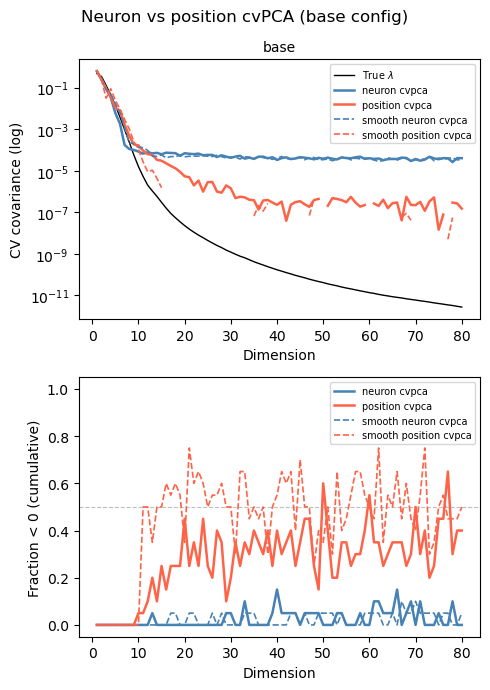

In [27]:
plot_results({"base": base_result}, suptitle="Neuron vs position cvPCA (base config)")
plt.show()

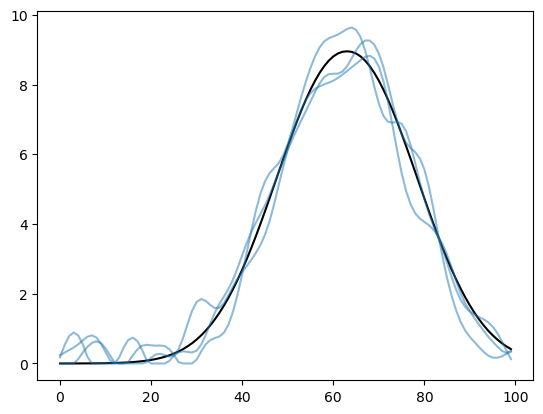

In [34]:
# Plot placefield examples
import random

idx_sim = 0
idx_neuron = random.randint(0, BASE.placefield.n_neurons - 1)
num_repeats = len(base_result["pf_data"][idx_sim]["repeats"])
plt.close("all")
plt.plot(base_result["pf_data"][idx_sim]["source"][idx_neuron], color="k", linewidth=1.5)
for i in range(num_repeats):
    plt.plot(base_result["pf_data"][idx_sim]["repeats"][i][idx_neuron], color="C0", alpha=0.5)
plt.show()

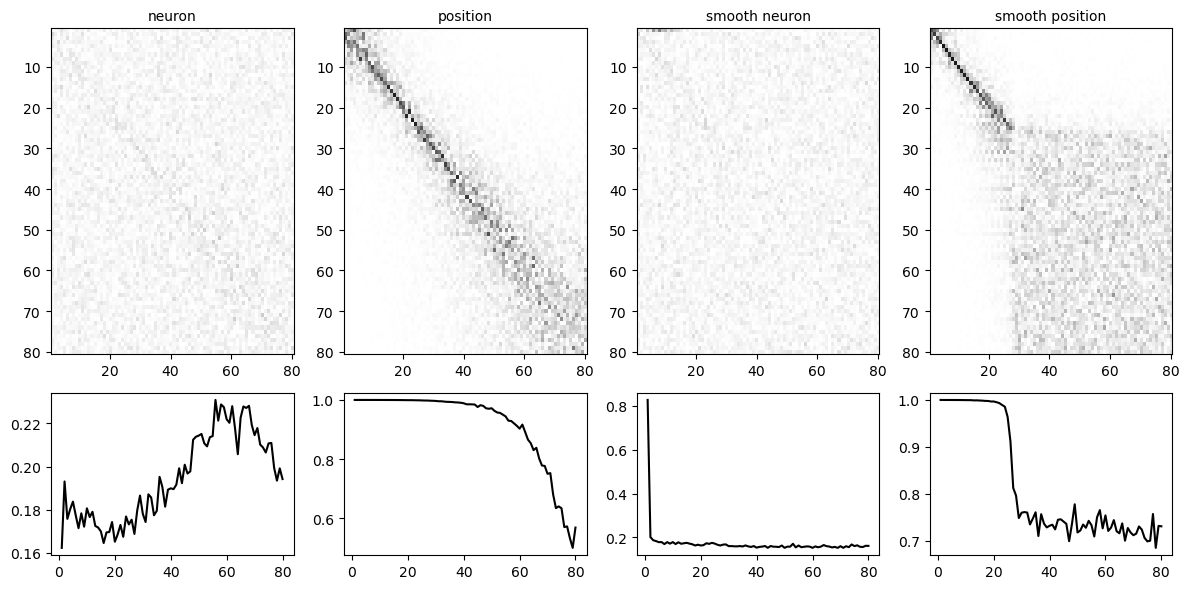

In [32]:
plot_components(base_result)
plt.show()

In [ ]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from my_precious_cvpca_simulation import plot_placefields
from study_cvpca_vs_stimspace import (
    BASE,
    SimulationConfig,
    PlacefieldConfig,
    config_from_params,
    plot_best_spectra,
    plot_component_pair,
    plot_frac_neg_pair,
    plot_study,
    print_best_configs,
    run_full_simulations,
    run_study,
)
from dataclasses import replace

In [14]:
# ---- study config ----
N_TRIALS = 100
N_SIMS_PER_TRIAL = 10
DEVICE = "cpu"
OPTUNA_SEED = 0

base = replace(
    BASE,
    placefield=replace(BASE.placefield, n_neurons=500, n_positions=100),
    n_components=80,
    n_simulations=N_SIMS_PER_TRIAL,
    seed=42,
)

study = run_study(base, n_trials=N_TRIALS, n_sims_per_trial=N_SIMS_PER_TRIAL, device=DEVICE, seed=OPTUNA_SEED)
print_best_configs(study, top_n=5)

  0%|          | 0/100 [00:00<?, ?it/s]


=== Top 5 configs by alpha_cvpca/alpha_stim ratio ===
#1  ratio=19.9947  trial=42  alpha_cvpca=12.350  alpha_stim=0.460
    pf_amp=25.32  ls=3.04  thr=66.8  rep_a=0.75  rep_ls=10.42
    peak_p=3.25  s_scale=2.18  noise=0.13  smooth=8.69  norm=True  center=True
#2  ratio=14.8515  trial=68  alpha_cvpca=5.538  alpha_stim=0.639
    pf_amp=27.04  ls=3.08  thr=68.9  rep_a=0.73  rep_ls=7.29
    peak_p=3.81  s_scale=1.47  noise=0.17  smooth=16.81  norm=False  center=False
#3  ratio=12.5987  trial=71  alpha_cvpca=7.010  alpha_stim=0.525
    pf_amp=23.43  ls=3.17  thr=59.7  rep_a=0.71  rep_ls=9.27
    peak_p=3.90  s_scale=1.62  noise=0.14  smooth=11.10  norm=False  center=False
#4  ratio=11.6423  trial=55  alpha_cvpca=5.211  alpha_stim=0.048
    pf_amp=13.79  ls=3.63  thr=71.4  rep_a=0.77  rep_ls=13.09
    peak_p=3.22  s_scale=1.30  noise=0.28  smooth=12.84  norm=True  center=False
#5  ratio=10.2336  trial=23  alpha_cvpca=4.875  alpha_stim=-0.040
    pf_amp=12.80  ls=8.49  thr=76.7  rep_a=0.78 

In [3]:
figs = plot_study(study)
figs["history"].show()
figs["parallel"].show()

In [16]:
# Best config + full simulations
N_FULL_SIMS = 20

cfg_best = config_from_params(study.best_trial.params, base)
print("Best config:")
print(f"  ratio={study.best_trial.value:.4f}")
for k, v in study.best_trial.params.items():
    print(f"  {k}={v}")


stacked = run_full_simulations(cfg_best, n_sims=N_FULL_SIMS, device=DEVICE)
print(f"\nMedian ratio:      {np.median(stacked['ratio']):.3f}")
print(f"\nMean ratio:      {stacked['ratio'].mean():.3f} +/- {stacked['ratio'].std():.3f}")
print(f"Mean alpha_cv:   {stacked['alpha_cvpca'].mean():.3f}")
print(f"Mean alpha_stim: {stacked['alpha_stim'].mean():.3f}")

Best config:
  ratio=19.9947
  pf_amplitude=25.320924241976183
  pf_lengthscale=3.0411818782622775
  pf_threshold_pct=66.80688097967794
  pf_repeat_noise_alpha=0.7470267225803113
  pf_repeat_noise_lengthscale=10.417748264568383
  peak_exponent=3.2482745039172225
  peak_sigma_scale=2.181182389338818
  noise_level=0.12670989974169103
  smooth_width=8.694721103764012
  normalize=True
  center=True


full simulations: 100%|██████████| 20/20 [00:00<00:00, 27.99it/s]


NameError: name 'np' is not defined

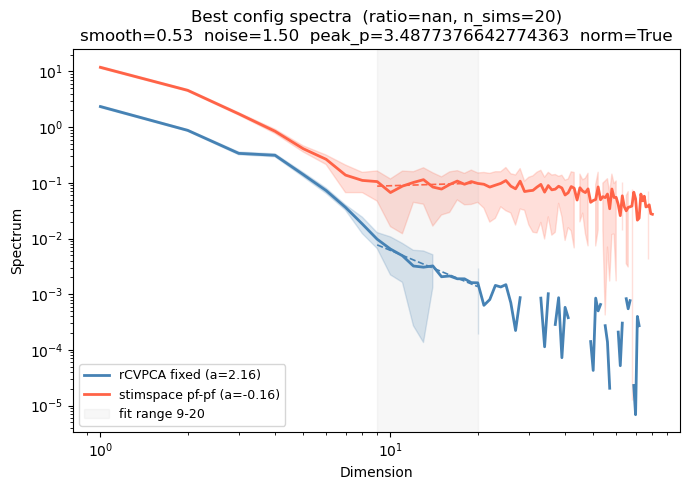

In [5]:
# Log-log spectra: rCVPCA fixed vs stimspace pf-pf
plot_best_spectra(cfg_best, n_sims=N_FULL_SIMS, device=DEVICE)
plt.show()

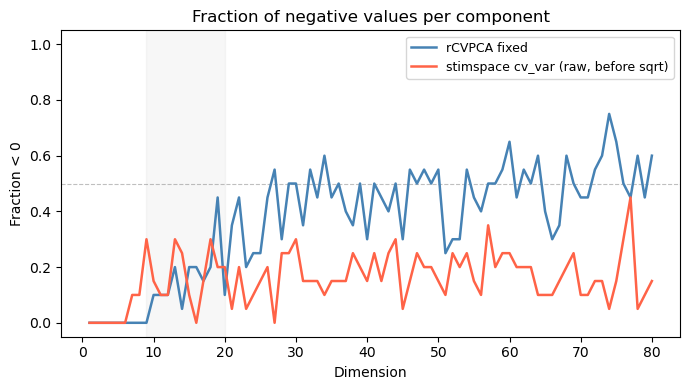

In [6]:
# Fraction of negatives
plot_frac_neg_pair(stacked)
plt.show()

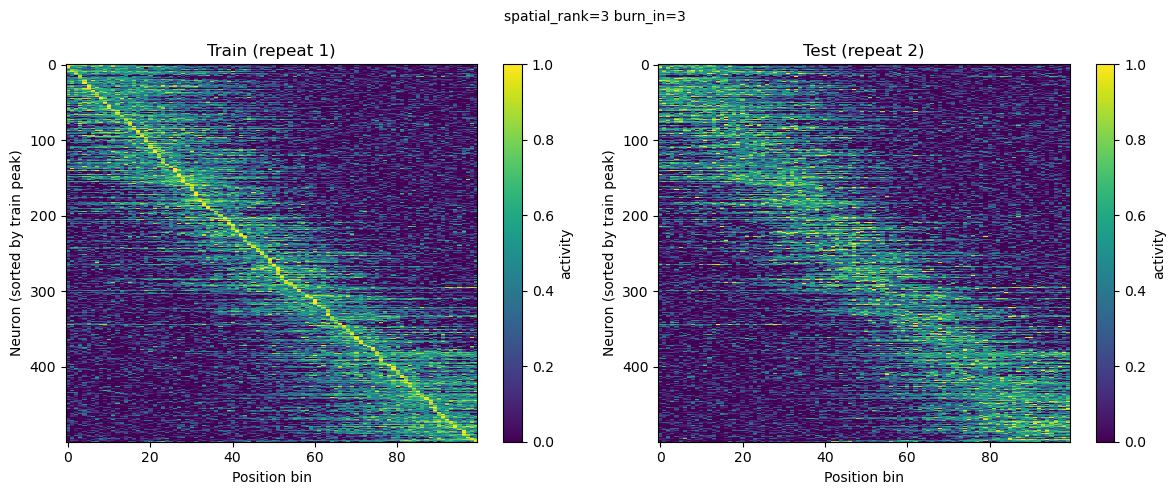

In [7]:
# Placefields: sorted heatmaps of train and test repeats
plot_placefields(cfg_best, device=DEVICE)
plt.show()

In [ ]:
print(stacked.keys())
for k in stacked:
    print(k, stacked[k].shape)

dict_keys(['reg_cov', 'cv_var_raw', 'stim_spec', 'cvpca_components', 'stim_u', 'source_comps_n', 'source_comps_p', 'alpha_cvpca', 'alpha_stim', 'ratio', 'frac_neg_reg_cov', 'frac_neg_cv_var_raw'])
reg_cov (20, 80)
cv_var_raw (20, 80)
stim_spec (20, 80)
cvpca_components (20, 100, 80)
stim_u (20, 100, 80)
source_comps_n (20, 500, 80)
source_comps_p (20, 100, 80)
alpha_cvpca (20,)
alpha_stim (20,)
ratio (20,)
frac_neg_reg_cov (80,)
frac_neg_cv_var_raw (80,)


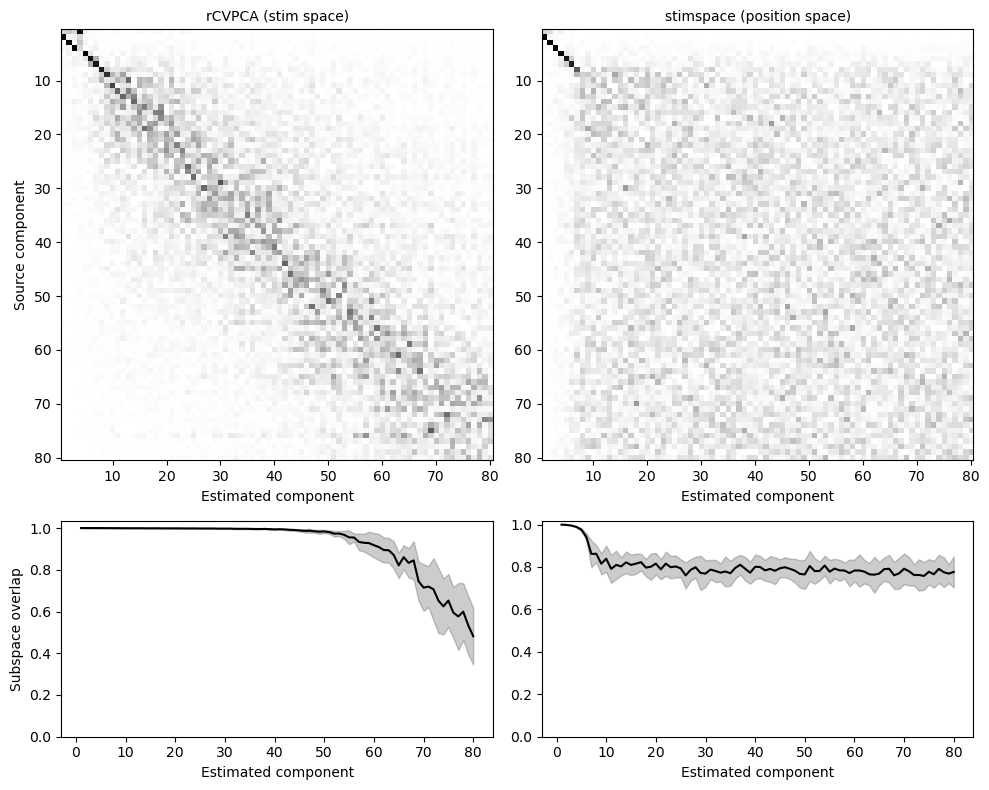

In [9]:
# Component comparison: rCVPCA (neuron space) and stimspace (position space) vs source SVD
plot_component_pair(stacked, n_show=80)
plt.show()